<a href="https://colab.research.google.com/github/Abhinraj175/Markov-chain-/blob/main/Monte%20Carlo(Markov).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install pandas numpy matplotlib scipy

Here we are generating synthetic rainfall series. That is continuous daily values, but not from the very next day of last observed rainfall value. It's a arbitery new timeline. Observed data is generated to obtain the transition probability matrix and other statistical observations.

In [7]:
#Load rainfall dataset
import pandas as pd

# load csv
rain = pd.read_csv("/content/drive/MyDrive/Markov chain/kuttanad_rainfall.csv")

# convert date column
rain['Date'] = pd.to_datetime(rain['Date'])

# sort data
rain = rain.sort_values("Date")

print(rain.head())

        Date   Rainfall  Unnamed: 2  Unnamed: 3  Unnamed: 4  \
0 1990-01-01   0.000000         NaN         NaN         NaN   
1 1990-01-02   0.625894         NaN         NaN         NaN   
2 1990-01-03  22.564243         NaN         NaN         NaN   
3 1990-01-04   0.000000         NaN         NaN         NaN   
4 1990-01-05   0.000000         NaN         NaN         NaN   

   Lat: 9.5000, Lon: 76.5000  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#Convert rainfall to wet/dry states
rain['state'] = (rain['Rainfall'] >= 1).astype(int)
rain['state'].value_counts()

,count
state,
0,5903
1,5420


In [9]:
#Calculate transition probabilities
import numpy as np

states = rain['state'].values

DD = DW = WD = WW = 0

for i in range(len(states)-1):

    if states[i] == 0 and states[i+1] == 0:
        DD += 1

    elif states[i] == 0 and states[i+1] == 1:
        DW += 1

    elif states[i] == 1 and states[i+1] == 0:
        WD += 1

    elif states[i] == 1 and states[i+1] == 1:
        WW += 1

In [10]:
#Compute probabilities
Pdd = DD / (DD + DW)
Pdw = DW / (DD + DW)

Pwd = WD / (WD + WW)
Pww = WW / (WD + WW)

print("Transition Matrix")

print([[Pdd, Pdw],
       [Pwd, Pww]])

Transition Matrix
[[0.7780789429103846, 0.22192105708961546], [0.24155748293042997, 0.75844251706957]]


In [11]:
#Fit rainfall distribution (for wet days)
from scipy.stats import gamma

wet_rain = rain[rain['Rainfall'] >= 1]['Rainfall']

shape, loc, scale = gamma.fit(wet_rain, floc=0)

print(shape, loc, scale)

1.0906925948817998 0 15.216965463111514


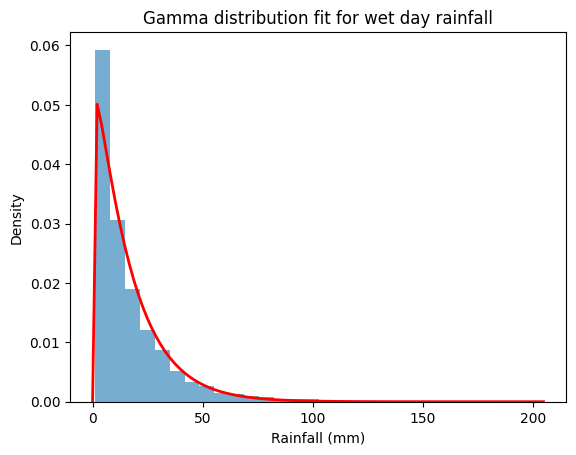

In [12]:
#Plot distribution fit
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, wet_rain.max(), 100)

pdf = gamma.pdf(x, shape, loc, scale)

plt.hist(wet_rain, bins=30, density=True, alpha=0.6)
plt.plot(x, pdf, 'r', linewidth=2)

plt.title("Gamma distribution fit for wet day rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Density")
plt.show()

In [13]:
#Simulate wet/dry rainfall sequence
sim_states = []

state = np.random.choice([0,1])

for i in range(10000):

    if state == 0:
        state = np.random.choice([0,1], p=[Pdd, Pdw])

    else:
        state = np.random.choice([0,1], p=[Pwd, Pww])

    sim_states.append(state)

In [14]:
#Generate rainfall amounts
sim_rain = []

for s in sim_states:

    if s == 1:
        r = gamma.rvs(shape, loc, scale)
    else:
        r = 0

    sim_rain.append(r)

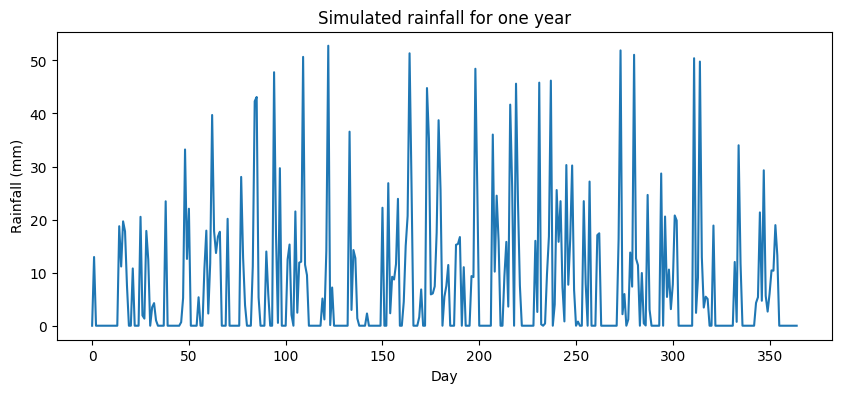

In [15]:
#Plot synthetic rainfall
plt.figure(figsize=(10,4))

plt.plot(sim_rain[:365])

plt.title("Simulated rainfall for one year")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.show()

In [16]:
#Compare observed vs simulated statistics
print("Observed mean rainfall:", rain['Rainfall'].mean())
print("Simulated mean rainfall:", np.mean(sim_rain))

print("Observed wet days:", (rain['Rainfall']>=1).mean())
print("Simulated wet days:", np.mean(sim_states))

Observed mean rainfall: 7.982060258843681
Simulated mean rainfall: 8.00238925791331
Observed wet days: 0.47867173010686215
Simulated wet days: 0.4776


In [17]:
import pandas as pd

#Save synthetic rainfall
sim_df = pd.DataFrame({
    "Rainfall": sim_rain
})

sim_df.to_csv("synthetic_rainfall.csv", index=False)
sim_df.to_csv("/content/drive/MyDrive/Markov chain/synthetic_rainfall.csv", index=False)

1000 simulations generated successfully
Shape of simulation array:
(1000, 10950)


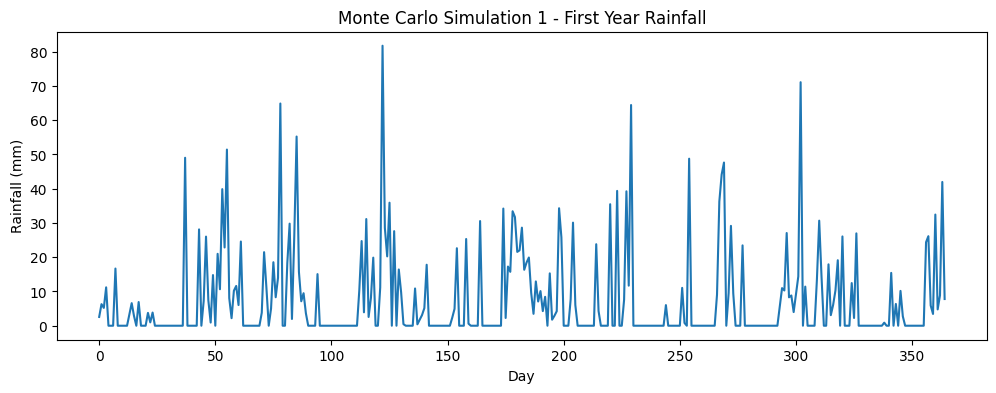

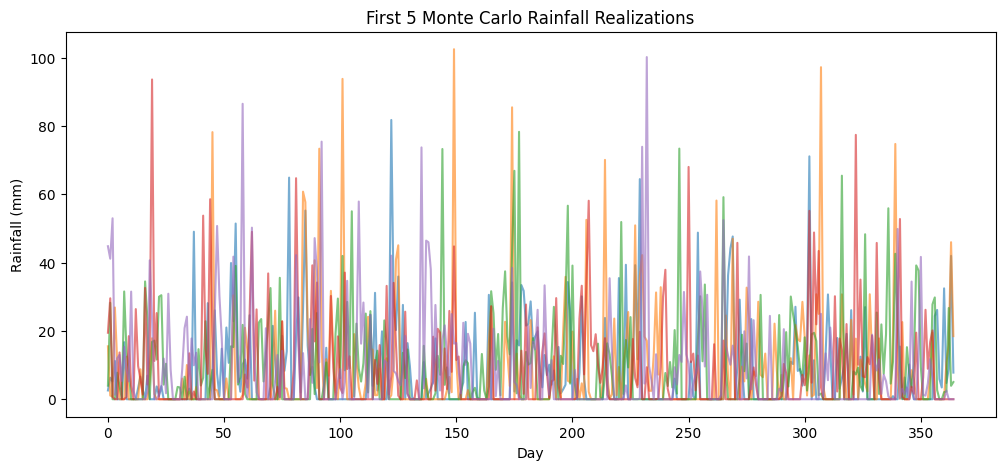


Observed Mean Rainfall: 7.98
Monte Carlo Mean Rainfall: 7.95

Monte Carlo rainfall realizations saved successfully.


In [18]:
# ============================================
# Monte Carlo Rainfall Simulation
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma

# -----------------------------
# Function to generate one synthetic rainfall series
# -----------------------------
def generate_rainfall_series(n_days):

    sim_states = []

    state = np.random.choice([0,1])

    for i in range(n_days):

        if state == 0:
            state = np.random.choice([0,1], p=[Pdd, Pdw])

        else:
            state = np.random.choice([0,1], p=[Pwd, Pww])

        sim_states.append(state)

    sim_rain = []

    for s in sim_states:

        if s == 1:
            rain = gamma.rvs(shape, loc=loc, scale=scale)

        else:
            rain = 0

        sim_rain.append(rain)

    return np.array(sim_rain)

# -----------------------------
# Monte Carlo Parameters
# -----------------------------
n_simulations = 1000

years_per_simulation = 30

days_per_year = 365

simulation_length = years_per_simulation * days_per_year

# -----------------------------
# Run Monte Carlo
# -----------------------------
all_simulations = []

for i in range(n_simulations):

    rainfall_series = generate_rainfall_series(simulation_length)

    all_simulations.append(rainfall_series)

print(f"{n_simulations} simulations generated successfully")

# -----------------------------
# Convert to array
# -----------------------------
all_simulations = np.array(all_simulations)

print("Shape of simulation array:")
print(all_simulations.shape)

# Expected:
# (1000, 10950)

# -----------------------------
# Plot first year from first simulation
# -----------------------------
plt.figure(figsize=(12,4))

plt.plot(all_simulations[0][:365])

plt.title("Monte Carlo Simulation 1 - First Year Rainfall")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.show()

# -----------------------------
# Plot first 5 realizations
# -----------------------------
plt.figure(figsize=(12,5))

for i in range(5):

    plt.plot(all_simulations[i][:365], alpha=0.6)

plt.title("First 5 Monte Carlo Rainfall Realizations")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.show()

# -----------------------------
# Compare statistics
# -----------------------------
observed_mean = rain['Rainfall'].mean()

simulated_mean = all_simulations.mean()

print("\nObserved Mean Rainfall:", round(observed_mean,2))

print("Monte Carlo Mean Rainfall:", round(simulated_mean,2))

# -----------------------------
# Save Monte Carlo realizations
# -----------------------------
mc_df = pd.DataFrame(all_simulations.T)

mc_df.columns = [f"Simulation_{i+1}" for i in range(n_simulations)]

mc_df.to_csv(
    "/content/drive/MyDrive/Markov chain/MonteCarlo_Rainfall_1000Runs.csv",
    index=False
)

print("\nMonte Carlo rainfall realizations saved successfully.")